# Model Tambahan: Menebak Kategori dan Rating dari Teks Ulasan

Notebook ini mencoba dua tugas lain yang disarankan untuk dataset ulasan:

- Bagian A, klasifikasi kategori: menebak kategori produk (elektronik, fashion, olahraga, handphone, pertukangan) hanya dari teks ulasan.
- Bagian B, prediksi rating: menebak bintang 1 sampai 5 dari teks ulasan.

Pola kerjanya sama dengan `06_model_sentimen.ipynb`: data dibagi dulu, pengaturan model dipilih dengan cross-validation di data latih, lalu model dinilai sekali di data uji.

Kedua model ini tidak dipakai di dashboard. Tujuannya menguji seberapa jauh teks ulasan bisa dipakai untuk tugas lain, dan membandingkan hasilnya dengan model sentimen dua kelas.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)
from sklearn.model_selection import (
    GridSearchCV,
    GroupShuffleSplit,
    StratifiedGroupKFold,
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.pipeline import Pipeline

# Folder utama proyek dimasukkan ke daftar pencarian modul, supaya folder src bisa di-import
sys.path.append(str(Path("..").resolve()))
from src.teks import bersihkan_teks

In [2]:
# Gaya grafik, sama dengan notebook sebelumnya
BIRU = "#2a78d6"
ORANYE = "#eb6834"
ABU = "#c8c6bf"
TEKS = "#52514e"

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#8a8983",
    "axes.labelcolor": TEKS,
    "xtick.color": TEKS,
    "ytick.color": TEKS,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e6e5e0",
    "grid.linewidth": 0.8,
})

PETA_BIRU = LinearSegmentedColormap.from_list("biru", ["#f4f3ef", BIRU])


def gambar_confusion(matriks_persen, label, judul):
    fig, ax = plt.subplots(figsize=(5.8, 4.6))
    ax.imshow(matriks_persen, cmap=PETA_BIRU, vmin=0, vmax=100)
    ax.set_xticks(range(len(label)), labels=label, rotation=30, ha="right")
    ax.set_yticks(range(len(label)), labels=label)
    for i in range(len(label)):
        for j in range(len(label)):
            ax.text(j, i, f"{matriks_persen[i, j]:.0f}%", ha="center", va="center", fontsize=9, color="#0b0b0b")
    ax.set_xlabel("Tebakan model")
    ax.set_ylabel("Label asli")
    ax.grid(False)
    ax.set_title(judul)
    plt.tight_layout()
    plt.show()

## Menyiapkan data

Prediksi rating butuh ulasan bintang 3, padahal bintang 3 sudah dibuang dari `ulasan_bersih.csv`. Karena itu data diambil lagi dari file mentah dan dibersihkan ulang.

Fungsi `bersihkan_teks` kini disimpan di file `src/teks.py`, bukan disalin ulang ke notebook ini. Dengan begitu notebook ini, notebook-notebook lain, dan dashboard nanti memakai satu fungsi yang sama. Sel di bawah memastikan hasilnya sama persis dengan hasil notebook 05.

In [3]:
df = pd.read_csv("../Dataset/raw/tokopedia-product-reviews-2019.csv")
df = df.drop_duplicates(subset=["text", "product_id"])
df["teks_bersih"] = df["text"].map(bersihkan_teks)
df = df[df["teks_bersih"].str.strip() != ""].reset_index(drop=True)
print(df.shape)

(40390, 10)


In [4]:
# Hasil src/teks.py harus sama dengan hasil notebook 05
ulasan_bersih = pd.read_csv("../Dataset/processed/ulasan_bersih.csv")
cocok = df.merge(ulasan_bersih, left_on=["text", "product_id"], right_on=["teks", "id_produk"],
                 suffixes=("", "_nb05"))
assert (cocok["teks_bersih"] == cocok["teks_bersih_nb05"].fillna("")).all()
print(f"{len(cocok):,} ulasan diperiksa, semuanya sama.")

38,585 ulasan diperiksa, semuanya sama.


In [5]:
def buat_pipeline(**pengaturan_model):
    return Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
        ("model", LogisticRegression(max_iter=3000, **pengaturan_model)),
    ])


GRID = {
    "model__C": [1, 10],
    "model__class_weight": [None, "balanced"],
}

## Bagian A: Klasifikasi kategori

### A1. Membagi data per produk

Pembagian acak berisiko untuk tugas ini. Ulasan untuk produk yang sama sering menyebut nama atau ciri produk itu, misalnya "headsetnya" atau "sepatunya". Kalau ulasan dari produk yang sama tersebar di data latih dan data uji, model bisa sekadar menghafal produk, bukan belajar mengenali kategori.

Karena itu data dibagi per produk dengan `GroupShuffleSplit`: semua ulasan dari satu produk masuk ke data latih saja atau data uji saja. Cross-validation juga dibagi per produk dengan `StratifiedGroupKFold`.

In [6]:
X = df["teks_bersih"]
y_kategori = df["category"]
produk = df["product_id"]

pembagi = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx_latih, idx_uji = next(pembagi.split(X, y_kategori, groups=produk))

X_latih, X_uji = X.iloc[idx_latih], X.iloc[idx_uji]
y_latih, y_uji = y_kategori.iloc[idx_latih], y_kategori.iloc[idx_uji]
produk_latih = produk.iloc[idx_latih]

print("Data latih:", len(X_latih), "| Data uji:", len(X_uji))
print("Produk yang ada di keduanya:", len(set(produk_latih) & set(produk.iloc[idx_uji])))
pd.DataFrame({"latih": y_latih.value_counts(normalize=True), "uji": y_uji.value_counts(normalize=True)}).round(3)

Data latih: 29887 | Data uji: 10503
Produk yang ada di keduanya: 0


,latih,uji
category,,
elektronik,0.393,0.390
fashion,0.205,0.259
olahraga,0.200,0.172
handphone,0.151,0.150
pertukangan,0.051,0.028


### A2. Model patokan

Model patokan selalu menebak kategori terbanyak, yaitu elektronik.

Ukuran utama yang dipakai adalah macro F1, yaitu rata-rata F1 dari kelima kategori dengan bobot yang sama. Akurasi saja kurang adil, karena elektronik jauh lebih banyak dari kategori lain. Model yang pandai menebak elektronik tetapi gagal di pertukangan tetap bisa mendapat akurasi tinggi, sedangkan macro F1-nya akan rendah.

In [7]:
patokan = DummyClassifier(strategy="most_frequent").fit(X_latih, y_latih)
tebakan = patokan.predict(X_uji)
print(f"Akurasi: {accuracy_score(y_uji, tebakan):.3f} | macro F1: {f1_score(y_uji, tebakan, average='macro'):.3f}")

Akurasi: 0.390 | macro F1: 0.112


### A3. Memilih pengaturan dengan GridSearchCV

In [8]:
grid_kategori = GridSearchCV(
    buat_pipeline(),
    GRID,
    scoring="f1_macro",
    cv=StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=2,
)
grid_kategori.fit(X_latih, y_latih, groups=produk_latih)

print("Pengaturan terbaik:", grid_kategori.best_params_)
print(f"Macro F1 cross-validation: {grid_kategori.best_score_:.3f}")

Pengaturan terbaik: {'model__C': 1, 'model__class_weight': 'balanced'}
Macro F1 cross-validation: 0.359


### A4. Evaluasi di data uji

In [9]:
model_kategori = grid_kategori.best_estimator_
tebakan_kategori = model_kategori.predict(X_uji)
print(classification_report(y_uji, tebakan_kategori, digits=3))

              precision    recall  f1-score   support

  elektronik      0.639     0.436     0.518      4098
     fashion      0.549     0.418     0.475      2725
   handphone      0.290     0.353     0.319      1578
    olahraga      0.317     0.392     0.350      1805
 pertukangan      0.062     0.310     0.103       297

    accuracy                          0.407     10503
   macro avg      0.371     0.382     0.353     10503
weighted avg      0.492     0.407     0.436     10503



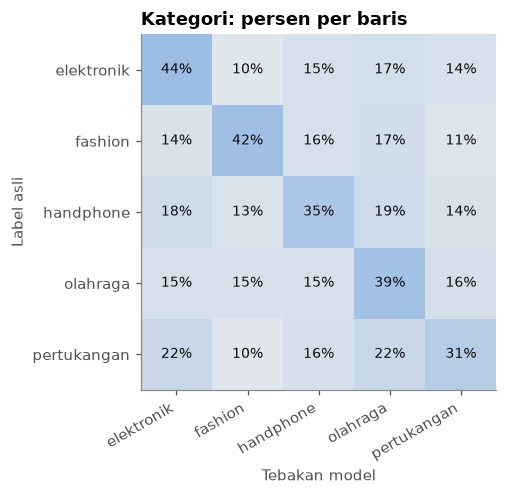

In [10]:
label_kategori = sorted(y_kategori.unique())
matriks = confusion_matrix(y_uji, tebakan_kategori, labels=label_kategori)
matriks_persen = matriks / matriks.sum(axis=1, keepdims=True) * 100
gambar_confusion(matriks_persen, label_kategori, "Kategori: persen per baris")

Setiap baris confusion matrix di atas dijumlahkan menjadi 100%. Baris "fashion", misalnya, menunjukkan ke mana saja ulasan fashion ditebak oleh model. Angka di diagonal adalah persentase yang ditebak benar.

### A5. Kata yang paling khas untuk setiap kategori

In [11]:
kosakata = model_kategori.named_steps["tfidf"].get_feature_names_out()
bobot = model_kategori.named_steps["model"].coef_

kata_khas = pd.DataFrame({
    kategori: kosakata[np.argsort(bobot[i])[::-1][:10]]
    for i, kategori in enumerate(model_kategori.classes_)
})
kata_khas

,elektronik,fashion,handphone,olahraga,pertukangan
0,tinta,sepatunya,hp,bola,isinya
1,berfungsi,sepatu,suara,olahraga,isi
2,laptop,jamnya,suaranya,matras,staples
3,kabel,jam,tidak bisa,tebal,dicoba
4,mouse,bata,nokia,nyaman,kayu
5,lancar,ukuran,handphone,warung,kuat
6,baterai,suka,buat,bolanya,tembak
7,komputer,nyaman,holdernya,bahannya,gun
8,kabelnya,size,berfungsi,matrasnya,staplesnya
9,usb,diskon,seller pokoknya,surabaya,krisbow


### A6. Masalahnya di model atau di inputnya?

Untuk memisahkan dua kemungkinan itu, model yang sama persis dilatih dengan input berbeda: nama produk, bukan teks ulasan. Pengaturannya sama dengan model terpilih di A3, dan penilaiannya memakai cross-validation per produk di data latih. Kalau skornya tetap rendah, masalahnya di model. Kalau skornya melonjak, masalahnya di informasi yang tersedia di teks ulasan.

In [12]:
cv_grup = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
data_latih = df.iloc[idx_latih]
nama_produk_bersih = data_latih["product_name"].map(bersihkan_teks)

perbandingan_input = {}
tebakan_cv = {}
for nama, masukan in [("teks ulasan", X_latih), ("nama produk", nama_produk_bersih)]:
    tebakan_cv[nama] = cross_val_predict(
        buat_pipeline(C=grid_kategori.best_params_["model__C"], class_weight=grid_kategori.best_params_["model__class_weight"]),
        masukan, y_latih, cv=cv_grup, groups=produk_latih, n_jobs=2,
    )
    perbandingan_input[nama] = {
        "akurasi": accuracy_score(y_latih, tebakan_cv[nama]),
        "macro_f1": f1_score(y_latih, tebakan_cv[nama], average="macro"),
    }
pd.DataFrame(perbandingan_input).T.round(3)

,akurasi,macro_f1
teks ulasan,0.405,0.359
nama produk,0.972,0.974


Dengan nama produk, model yang sama menebak kategori dengan hampir sempurna. Jadi modelnya mampu. Yang kurang adalah petunjuk di teks ulasan.

Petunjuk itu makin banyak kalau ulasannya makin panjang, karena pembeli baru menyebut produknya setelah selesai membahas pengiriman dan penjual:

In [13]:
panjang = X_latih.str.split().str.len()
benar = tebakan_cv["teks ulasan"] == y_latih.to_numpy()
kelompok = pd.cut(panjang, bins=[0, 3, 8, 20, 10_000], labels=["1-3 kata", "4-8 kata", "9-20 kata", "lebih dari 20 kata"])
pd.DataFrame({"porsi ulasan": kelompok.value_counts(normalize=True).sort_index(),
              "akurasi": pd.Series(benar).groupby(kelompok.to_numpy()).mean()}).round(2)

,porsi ulasan,akurasi
1-3 kata,0.13,0.29
4-8 kata,0.58,0.38
9-20 kata,0.25,0.50
lebih dari 20 kata,0.04,0.60


### Kesimpulan bagian A

Klasifikasi kategori dari teks ulasan hanya berhasil sebagian, dan A6 menunjukkan penyebabnya ada di input, bukan di model:

- Akurasinya sekitar 41%, hampir sama dengan model patokan (39%). Yang jauh lebih baik adalah macro F1 (sekitar 0,35 dibanding 0,11), karena model mau menebak kategori selain elektronik. Namun precision untuk pertukangan hanya sekitar 6%, artinya hampir semua tebakan "pertukangan" salah.
- Penyebab utamanya terlihat dari data: sebagian besar ulasan membahas hal yang sama di semua kategori, seperti "barang sesuai pesanan" dan "pengiriman cepat", tanpa menyebut produknya. Model hanya bisa menebak dengan yakin kalau ulasan menyebut ciri produk, misalnya "sepatu" dan "ukuran" untuk fashion, atau "suara" dan "hp" untuk handphone.
- Kata khas yang dipelajari model juga berisi merek dan nama tempat, seperti "bata", "nokia", "krisbow", dan "surabaya". Data sudah dibagi per produk, tetapi toko dan merek yang sama tetap bisa muncul di data latih dan data uji. Jadi sebagian kemampuan model berasal dari menghafal merek atau toko, bukan memahami kategori.

Untuk menebak kategori, nama produk jauh lebih informatif daripada teks ulasan: model yang sama mencapai akurasi sekitar 97% dengan nama produk, dibanding sekitar 40% dengan teks ulasan. Ulasan pendek (median 6 kata) paling sulit ditebak. Teks ulasan lebih cocok dipakai untuk menilai pengalaman pembeli, seperti di model sentimen.

## Bagian B: Prediksi rating

### B1. Membagi data

Berbeda dengan bagian A dan notebook 06, data di bagian ini dibagi secara acak dengan `stratify`, supaya porsi setiap bintang sama di data latih dan data uji. Akibatnya skor bagian ini bisa sedikit optimis, karena ulasan dari produk yang sama bisa ada di kedua sisi. Di notebook 06 bagian 10a, selisih pembagian acak dan per produk hanya sekitar 0,01, dan temuan utama bagian ini (B5) dihitung dari seluruh data, jadi tidak bergantung pada cara membagi. Tugas ini memakai semua bintang, termasuk bintang 3.

Selain akurasi dan macro F1, dipakai juga MAE (mean absolute error): rata-rata selisih bintang antara tebakan dan label asli. MAE 0,3 berarti rata-rata tebakan meleset 0,3 bintang. Ukuran ini berguna karena salah menebak bintang 4 sebagai 5 jauh lebih ringan daripada salah menebak bintang 1 sebagai 5.

In [14]:
y_rating = df["rating"]
X_latih_r, X_uji_r, y_latih_r, y_uji_r = train_test_split(
    X, y_rating, test_size=0.2, stratify=y_rating, random_state=42
)
y_latih_r.value_counts(normalize=True).sort_index().round(3)

rating
1    0.013
2    0.009
3    0.045
4    0.186
5    0.747
Name: proportion, dtype: float64

### B2. Model patokan

In [15]:
def nilai_rating(asli, tebakan):
    return {
        "akurasi": accuracy_score(asli, tebakan),
        "macro_f1": f1_score(asli, tebakan, average="macro"),
        "mae": mean_absolute_error(asli, tebakan),
    }


patokan_r = DummyClassifier(strategy="most_frequent").fit(X_latih_r, y_latih_r)
hasil_rating = {"Patokan (selalu bintang 5)": nilai_rating(y_uji_r, patokan_r.predict(X_uji_r))}
pd.DataFrame(hasil_rating).T.round(3)

,akurasi,macro_f1,mae
Patokan (selalu bintang 5),0.747,0.171,0.357


### B3. Memilih pengaturan dengan GridSearchCV

In [16]:
grid_rating = GridSearchCV(
    buat_pipeline(),
    GRID,
    scoring="f1_macro",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=2,
)
grid_rating.fit(X_latih_r, y_latih_r)

print("Pengaturan terbaik:", grid_rating.best_params_)
print(f"Macro F1 cross-validation: {grid_rating.best_score_:.3f}")

Pengaturan terbaik: {'model__C': 1, 'model__class_weight': 'balanced'}
Macro F1 cross-validation: 0.372


### B4. Evaluasi di data uji

In [17]:
model_rating = grid_rating.best_estimator_
tebakan_rating = model_rating.predict(X_uji_r)

hasil_rating["Logistic Regression (terpilih, class_weight balanced)"] = nilai_rating(y_uji_r, tebakan_rating)
print(classification_report(y_uji_r, tebakan_rating, digits=3))

              precision    recall  f1-score   support

           1      0.333     0.620     0.434       108
           2      0.119     0.184     0.144        76
           3      0.170     0.380     0.235       361
           4      0.291     0.424     0.345      1501
           5      0.866     0.684     0.764      6032

    accuracy                          0.616      8078
   macro avg      0.356     0.458     0.384      8078
weighted avg      0.714     0.616     0.652      8078



Sebagai pembanding, model yang sama juga dilatih tanpa `class_weight`. Model ini tidak dipilih oleh GridSearchCV karena macro F1-nya sedikit lebih rendah, tetapi perbandingannya menunjukkan hal penting tentang pilihan ukuran.

In [18]:
model_tanpa_bobot = buat_pipeline(C=grid_rating.best_params_["model__C"]).fit(X_latih_r, y_latih_r)
hasil_rating["Logistic Regression (tanpa class_weight)"] = nilai_rating(y_uji_r, model_tanpa_bobot.predict(X_uji_r))
pd.DataFrame(hasil_rating).T.round(3)

,akurasi,macro_f1,mae
Patokan (selalu bintang 5),0.747,0.171,0.357
"Logistic Regression (terpilih, class_weight balanced)",0.616,0.384,0.487
Logistic Regression (tanpa class_weight),0.757,0.321,0.313


Hasilnya menunjukkan bahwa ukuran yang dipilih menentukan model mana yang terlihat "terbaik":

- Model terpilih (dengan `class_weight`) punya macro F1 tertinggi, tetapi akurasi dan MAE-nya justru lebih buruk daripada model patokan yang selalu menebak bintang 5. Model ini lebih berani menebak bintang rendah, sehingga lebih sering menemukan bintang 1, tetapi juga sering salah menurunkan ulasan bintang 5 menjadi 4 atau 3.
- Model tanpa `class_weight` punya akurasi dan MAE yang sedikit lebih baik dari patokan, tetapi menebak bintang 5 untuk sekitar 93% ulasan. Perilakunya hampir sama dengan model patokan.

Tidak ada satu pun model yang unggul di semua ukuran. Ini tanda bahwa tugasnya sendiri memang sulit dijawab dari teks ulasan.

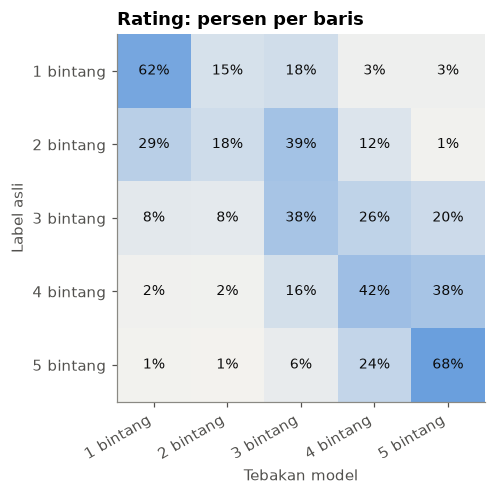

In [19]:
label_rating = [1, 2, 3, 4, 5]
matriks_r = confusion_matrix(y_uji_r, tebakan_rating, labels=label_rating)
matriks_r_persen = matriks_r / matriks_r.sum(axis=1, keepdims=True) * 100
gambar_confusion(matriks_r_persen, [f"{r} bintang" for r in label_rating], "Rating: persen per baris")

In [20]:
selisih = (pd.Series(tebakan_rating, index=y_uji_r.index) - y_uji_r).abs()
salah = selisih[selisih > 0]
print(f"Tebakan yang salah: {len(salah):,} ({len(salah) / len(selisih):.0%})")
print(f"Dari yang salah, meleset hanya 1 bintang: {(salah == 1).mean():.0%}")

Tebakan yang salah: 3,100 (38%)
Dari yang salah, meleset hanya 1 bintang: 79%


### B5. Teks yang sama, bintang yang berbeda

Kalau bintang 4 dan 5 memang tidak bisa dibedakan dari teksnya, seharusnya ada banyak ulasan dengan teks persis sama tetapi bintang berbeda. Tabel di bawah menghitung sebaran bintang untuk teks ulasan yang paling sering muncul.

In [21]:
sebaran = df.groupby("teks_bersih")["rating"].agg(
    jumlah="count",
    bintang_5=lambda s: (s == 5).mean(),
    bintang_4=lambda s: (s == 4).mean(),
    bintang_1_2=lambda s: (s <= 2).mean(),
)
sebaran.sort_values("jumlah", ascending=False).head(10).round(2)

,jumlah,bintang_5,bintang_4,bintang_1_2
teks_bersih,,,,
terimakasih,391,0.71,0.26,0.01
mantap,334,0.89,0.10,0.00
ok,223,0.62,0.31,0.00
barang sudah sampai terimakasih,162,0.70,0.22,0.00
terimakasih barang sudah sampai,152,0.64,0.34,0.00
barang sudah diterima terimakasih,128,0.65,0.30,0.00
good,125,0.83,0.15,0.00
bagus,123,0.76,0.22,0.00
sip,122,0.71,0.22,0.02


Dari sini bisa dihitung batas atas yang tidak bisa dilewati model mana pun. Untuk teks yang muncul lebih dari sekali, tebakan terbaik yang mungkin adalah bintang yang paling sering diberikan untuk teks itu. Tebakan itu pun tetap salah untuk sisanya.

In [22]:
ulasan_45 = df[df["rating"].isin([4, 5])]
per_teks = ulasan_45.groupby("teks_bersih")["rating"]
jumlah_teks = per_teks.size()
berulang = jumlah_teks[jumlah_teks > 1].index
porsi_mayoritas = per_teks.agg(lambda s: s.value_counts().iloc[0] / len(s))

kelompok_berulang = ulasan_45[ulasan_45["teks_bersih"].isin(berulang)]
batas_atas = (porsi_mayoritas[berulang] * jumlah_teks[berulang]).sum() / jumlah_teks[berulang].sum()
print(f"Ulasan bintang 4-5 yang teksnya muncul lebih dari sekali: {ulasan_45['teks_bersih'].isin(berulang).mean():.0%}")
print(f"Akurasi maksimum membedakan bintang 4 dan 5 di kelompok itu: {batas_atas:.1%}")
print(f"Akurasi kalau selalu menebak bintang 5 di kelompok yang sama: {(kelompok_berulang['rating'] == 5).mean():.1%}")

Ulasan bintang 4-5 yang teksnya muncul lebih dari sekali: 27%
Akurasi maksimum membedakan bintang 4 dan 5 di kelompok itu: 85.4%
Akurasi kalau selalu menebak bintang 5 di kelompok yang sama: 80.4%


Ulasan "terimakasih", misalnya, muncul ratusan kali dengan campuran bintang 4 dan 5. Di kelompok ulasan yang teksnya berulang, model sempurna pun hanya bisa unggul sekitar 5 poin dari tebakan "selalu bintang 5". Selisih satu bintang lebih banyak ditentukan kebiasaan masing-masing pembeli daripada isi ulasannya.

### Kesimpulan bagian B

Prediksi rating lima kelas jauh lebih sulit daripada sentimen dua kelas:

- Bintang 4 dan 5 hampir tidak bisa dibedakan dari teksnya. B5 membuktikannya: teks yang sama persis sering diberi bintang 4 oleh sebagian pembeli dan bintang 5 oleh yang lain. Pembeli yang memberi bintang 4 dan bintang 5 sering menulis kalimat yang sama, misalnya "barang bagus, pengiriman cepat". Perbedaan satu bintang itu lebih mencerminkan kebiasaan masing-masing pembeli daripada isi ulasannya.
- Bintang 2 dan 3 sangat sedikit dan isinya campuran, sehingga paling sering salah ditebak.
- Di antara bintang rendah, bintang 1 paling mudah dikenali (recall sekitar 62%), karena biasanya berisi keluhan yang jelas.
- Sebagian besar kesalahan hanya meleset satu bintang. Model memahami arah umum sentimennya, tetapi tidak bisa menebak angka pastinya.

Temuan ini mendukung keputusan di notebook 06 untuk menyederhanakan rating menjadi dua kelas (positif dan negatif). Dengan dua kelas, model menjawab pertanyaan yang memang bisa dijawab dari teks: apakah pembeli puas atau mengeluh.

## Ringkasan

| Tugas | Hasil | Catatan |
|---|---|---|
| Sentimen dua kelas (notebook 06) | F1 negatif sekitar 0,57 di data uji (cross-validation 0,62) | Paling berguna dan dipakai di dashboard |
| Klasifikasi kategori | Akurasi sekitar 41% (patokan 39%), macro F1 sekitar 0,35 | Ulasan jarang menyebut produknya, dan model sebagian menghafal merek. Dengan nama produk, model yang sama mencapai akurasi sekitar 97% |
| Prediksi rating 1 sampai 5 | Macro F1 sekitar 0,38, tetapi akurasi dan MAE tidak lebih baik dari patokan | Bintang 4 dan 5 tertukar. Teks yang sama persis sering diberi bintang berbeda |

Pelajaran dari notebook ini: cara merumuskan pertanyaan sama pentingnya dengan pilihan model. Teks ulasan yang sama bisa menghasilkan model yang berguna (sentimen) atau kurang berguna (rating lima kelas), tergantung pertanyaan yang diajukan.